Device: cpu
Mounted at /content/drive

Files in dataset folder:
['cifar-10-batches-py', 'cifar-10-python.tar.gz']

CIFAR-10 already extracted.

Extracted files:
['cifar-10-batches-py', 'cifar-10-python.tar.gz']

Classes:
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Training images: 50000
Testing images: 10000

Model:
SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=256, bias=True)
    (2): ReLU()
   

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch [1/10] Loss: 1.4321 Accuracy: 48.60%
Epoch [2/10] Loss: 0.9595 Accuracy: 66.02%
Epoch [3/10] Loss: 0.7660 Accuracy: 73.26%
Epoch [4/10] Loss: 0.6322 Accuracy: 78.18%
Epoch [5/10] Loss: 0.5119 Accuracy: 82.17%
Epoch [6/10] Loss: 0.3949 Accuracy: 86.08%
Epoch [7/10] Loss: 0.2773 Accuracy: 90.39%
Epoch [8/10] Loss: 0.1859 Accuracy: 93.64%
Epoch [9/10] Loss: 0.1159 Accuracy: 96.08%
Epoch [10/10] Loss: 0.0813 Accuracy: 97.21%

================ PRIVATE IMAGE ================

True label: cat


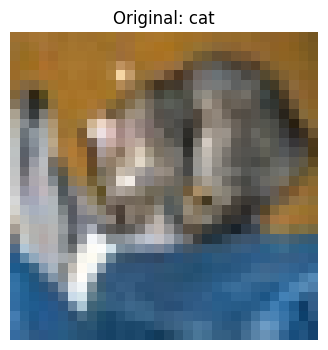

Actual class: cat
Predicted class: cat

Private image loss: 0.011194988153874874

================ LEAKED GRADIENTS ================

features.0.weight              Shape=(32, 3, 3, 3)        Norm=6.44655526e-01
features.0.bias                Shape=(32,)                Norm=2.74420738e-01
features.2.weight              Shape=(64, 32, 3, 3)       Norm=3.48404825e-01
features.2.bias                Shape=(64,)                Norm=1.63047314e-01
features.5.weight              Shape=(128, 64, 3, 3)      Norm=3.98310095e-01
features.5.bias                Shape=(128,)               Norm=6.88859448e-02
classifier.1.weight            Shape=(256, 8192)          Norm=3.66343319e-01
classifier.1.bias              Shape=(256,)               Norm=1.04352385e-02
classifier.3.weight            Shape=(10, 256)            Norm=7.78013408e-01
classifier.3.bias              Shape=(10,)                Norm=1.57437883e-02

Dummy image shape: torch.Size([1, 3, 32, 32])
Dummy min: 7.349252700805664e-05
Dummy 

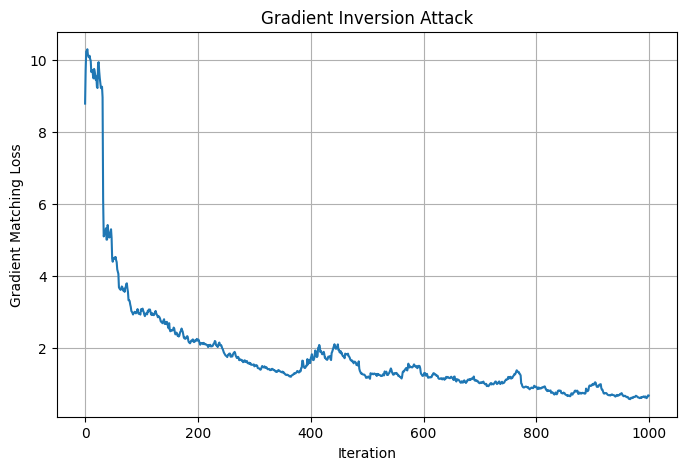

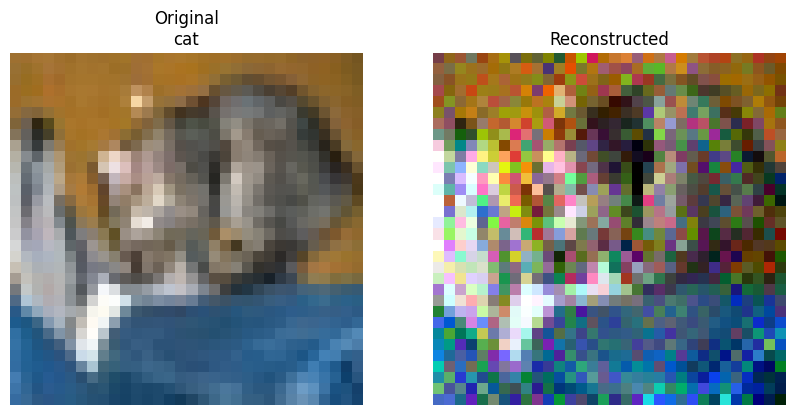


Reconstruction MSE: 0.0252531785517931
Original label: cat
Reconstructed image predicted label: cat


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

import matplotlib.pyplot as plt
import numpy as np

from google.colab import drive


torch.manual_seed(42)
np.random.seed(42)

#DEVICE

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)



# MOUNT GOOGLE DRIVE


drive.mount("/content/drive")


# 5. CIFAR-10 DATASET PATH
dataset_path = "/content/drive/MyDrive/datasets"

tar_path = (
    "/content/drive/MyDrive/datasets/"
    "cifar-10-python.tar.gz"
)

print("\nFiles in dataset folder:")

import os

print(os.listdir(dataset_path))


# 6. EXTRACT CIFAR-10

import tarfile

cifar_folder = os.path.join(
    dataset_path,
    "cifar-10-batches-py"
)

if not os.path.exists(cifar_folder):

    print("\nExtracting CIFAR-10...")

    with tarfile.open(
        tar_path,
        "r:gz"
    ) as tar:

        tar.extractall(
            path=dataset_path
        )

    print("Extraction completed!")

else:

    print("\nCIFAR-10 already extracted.")


print(
    "\nExtracted files:"
)

print(
    os.listdir(dataset_path)
)

# 7. LOAD CIFAR-10


transform = transforms.Compose([
    transforms.ToTensor()
])


train_dataset = torchvision.datasets.CIFAR10(
    root=dataset_path,
    train=True,
    download=False,
    transform=transform
)


test_dataset = torchvision.datasets.CIFAR10(
    root=dataset_path,
    train=False,
    download=False,
    transform=transform
)


classes = train_dataset.classes


print("\nClasses:")
print(classes)

print(
    "\nTraining images:",
    len(train_dataset)
)

print(
    "Testing images:",
    len(test_dataset)
)


# 8. DEFINE CNN MODEL

class SimpleCNN(nn.Module):

    def __init__(self):

        super(SimpleCNN, self).__init__()

        self.features = nn.Sequential(

            # Input:
            # 3 x 32 x 32

            nn.Conv2d(
                3,
                32,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            # 32 x 32 x 32

            nn.Conv2d(
                32,
                64,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            # 64 x 32 x 32

            nn.MaxPool2d(2),

            # 64 x 16 x 16

            nn.Conv2d(
                64,
                128,
                kernel_size=3,
                padding=1
            ),

            nn.ReLU(),

            # 128 x 16 x 16

            nn.MaxPool2d(2)

            # 128 x 8 x 8
        )


        self.classifier = nn.Sequential(

            nn.Flatten(),

            # 128 x 8 x 8
            # = 8192

            nn.Linear(
                128 * 8 * 8,
                256
            ),

            nn.ReLU(),

            nn.Linear(
                256,
                10
            )
        )


    def forward(self, x):

        x = self.features(x)

        x = self.classifier(x)

        return x


# 9. CREATE MODEL

model = SimpleCNN().to(device)

criterion = nn.CrossEntropyLoss()

print("\nModel:")
print(model)


# 10. CREATE DATA LOADER

train_loader = torch.utils.data.DataLoader(

    train_dataset,

    batch_size=128,

    shuffle=True,

    num_workers=2,

    pin_memory=True
)


# 11. TRAIN MODEL

optimizer = optim.Adam(

    model.parameters(),

    lr=0.001
)


epochs = 10


print("\n TRAINING \n")


for epoch in range(epochs):

    model.train()

    running_loss = 0.0

    correct = 0

    total = 0


    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.to(device)


        # Clear gradients

        optimizer.zero_grad()


        # Forward

        outputs = model(images)


        # Loss

        loss = criterion(
            outputs,
            labels
        )


        # Backpropagation

        loss.backward()


        # Update weights

        optimizer.step()


        running_loss += loss.item()


        # Accuracy

        _, predicted = outputs.max(1)


        total += labels.size(0)


        correct += (
            predicted == labels
        ).sum().item()


    accuracy = (
        100 * correct / total
    )


    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: "
        f"{running_loss / len(train_loader):.4f} "
        f"Accuracy: "
        f"{accuracy:.2f}%"
    )

# 12. SELECT ONE PRIVATE CIFAR IMAGE

# For our first GIA experiment we use an actual CIFAR-10 image.

image_tensor, true_label = test_dataset[0]


image_input = (
    image_tensor
    .unsqueeze(0)
    .to(device)
)


label_tensor = torch.tensor(
    [true_label],
    device=device
)


print("\n PRIVATE IMAGE \n")

print(
    "True label:",
    classes[true_label]
)


# Display original image

plt.figure(figsize=(4,4))

plt.imshow(
    image_tensor.permute(1,2,0)
)

plt.title(
    "Original: "
    + classes[true_label]
)

plt.axis("off")

plt.show()


# 13. CLASSIFY PRIVATE IMAGE

model.eval()


with torch.no_grad():

    output = model(
        image_input
    )


predicted_index = (
    output.argmax(dim=1).item()
)


print(
    "Actual class:",
    classes[true_label]
)

print(
    "Predicted class:",
    classes[predicted_index]
)

# 14. CALCULATE PRIVATE LOSS

model.zero_grad()


output = model(
    image_input
)


loss = criterion(
    output,
    label_tensor
)


print(
    "\nPrivate image loss:",
    loss.item()
)

# 15. CALCULATE LEAKED GRADIENT

leaked_gradients = torch.autograd.grad(

    loss,

    model.parameters(),

    create_graph=False
)


# Detach from computation graph

leaked_gradients = [

    g.detach().clone()

    for g in leaked_gradients
]


print(
    "\n================ LEAKED GRADIENTS ================\n"
)


for name, gradient in zip(

    [name for name, _ in model.named_parameters()],

    leaked_gradients

):

    print(
        f"{name:30s} "
        f"Shape={str(tuple(gradient.shape)):20s} "
        f"Norm={gradient.norm().item():.8e}"
    )

# 16. GRADIENT MATCHING FUNCTION

import torch.nn.functional as F


def gradient_matching_loss(

    dummy_gradients,

    leaked_gradients

):

    loss = 0.0


    for dg, lg in zip(

        dummy_gradients,

        leaked_gradients

    ):

        # Flatten gradients

        dg_flat = dg.reshape(-1)

        lg_flat = lg.reshape(-1)


        # Cosine similarity

        cosine = F.cosine_similarity(

            dg_flat.unsqueeze(0),

            lg_flat.unsqueeze(0),

            dim=1

        )


        # Cosine distance

        loss += (
            1 - cosine
        )


    return loss


# 17. CREATE RANDOM DUMMY IMAGE

dummy_data = torch.rand(

    image_input.shape,

    device=device,

    requires_grad=True

)


#  attacker knows the label

dummy_label = label_tensor.clone()


print(
    "\nDummy image shape:",
    dummy_data.shape
)

print(
    "Dummy min:",
    dummy_data.min().item()
)

print(
    "Dummy max:",
    dummy_data.max().item()
)


# Save initial dummy image

initial_dummy = (
    dummy_data.detach().clone()
)


# 18. ATTACK OPTIMIZER

optimizer_attack = optim.Adam(

    [dummy_data],

    lr=0.01
)


# 19. GRADIENT INVERSION ATTACK

iterations = 1000

history = []


print(
    "\n================ GIA ATTACK ================\n"
)


for iteration in range(iterations):


    # Clear old dummy gradients

    optimizer_attack.zero_grad()


    # Forward pass using dummy image

    dummy_output = model(
        dummy_data
    )


    # Calculate dummy loss

    dummy_loss = criterion(

        dummy_output,

        dummy_label
    )


    # Calculate gradient of model parameters

    dummy_gradients = torch.autograd.grad(

        dummy_loss,

        model.parameters(),

        create_graph=True
    )

    # Gradient matching loss

    grad_loss = gradient_matching_loss(

        dummy_gradients,

        leaked_gradients
    )

    # Backpropagate gradient matching loss


    grad_loss.backward()


    # Update dummy image

    optimizer_attack.step()


    # Keep pixels in [0,1]

    with torch.no_grad():

        dummy_data.clamp_(
            0,
            1
        )
    # Save loss


    loss_value = (
        grad_loss.item()
    )


    history.append(
        loss_value
    )


    # Print progress
    if iteration % 50 == 0:

        print(

            f"Iteration "
            f"{iteration:4d} | "

            f"Gradient Loss = "
            f"{loss_value:.8f}"

        )


# 20. CHECK WHETHER DUMMY IMAGE CHANGED

change = torch.mean(

    torch.abs(

        dummy_data.detach()
        -
        initial_dummy

    )

)


print(
    "\nAverage dummy image change:",
    change.item()
)

# 21. PLOT ATTACK LOSS

plt.figure(
    figsize=(8,5)
)


plt.plot(
    history
)


plt.xlabel(
    "Iteration"
)


plt.ylabel(
    "Gradient Matching Loss"
)


plt.title(
    "Gradient Inversion Attack"
)


plt.grid()


plt.show()


# 22. DISPLAY ORIGINAL VS RECONSTRUCTED

plt.figure(
    figsize=(10,5)
)


# Original

plt.subplot(
    1,
    2,
    1
)


original = (
    image_input[0]
    .detach()
    .cpu()
    .permute(1,2,0)
)


plt.imshow(
    original
)


plt.title(
    "Original\n"
    + classes[true_label]
)


plt.axis("off")

# Reconstructed

plt.subplot(
    1,
    2,
    2
)


reconstructed = (

    dummy_data[0]
    .detach()
    .cpu()
    .permute(1,2,0)
)


plt.imshow(
    reconstructed
)


plt.title(
    "Reconstructed"
)


plt.axis("off")


plt.show()


# 23. CALCULATE PIXEL MSE

mse = torch.mean(

    (
        image_input.detach()
        -
        dummy_data.detach()
    ) ** 2

)


print(
    "\nReconstruction MSE:",
    mse.item()
)


# 24. CLASSIFY RECONSTRUCTED IMAGE

model.eval()


with torch.no_grad():

    reconstructed_output = model(
        dummy_data
    )


reconstructed_prediction = (

    reconstructed_output
    .argmax(dim=1)
    .item()

)


print(
    "Original label:",
    classes[true_label]
)


print(
    "Reconstructed image predicted label:",
    classes[reconstructed_prediction]
)
